# ARCHS4 reconstruction error — % coverage models, random subsamples (plots)

**Environment:** `clamp-analyses`

Loads pre-computed reconstruction error results and generates plots.

Inputs: `output/01_model_building/06_reconstruction_error/reconstruction_error_results.rds` and `reconstruction_error_summary.csv`

Outputs: `output/01_model_building/06_reconstruction_error/`

## Load libraries

In [1]:
library(data.table)
library(dplyr)
library(ggplot2)
library(here)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:data.table’:

    between, first, last




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




here() starts at /home/msubirana/Documents/pivlab/clamp-analyses



## Parameters

In [2]:
output_dir <- here("output", "01_model_building", "06_reconstruction_error")
message("Output dir: ", output_dir)

Output dir: /home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/06_reconstruction_error



## Load results

In [3]:
results_list <- readRDS(file.path(output_dir, "reconstruction_error_random_results.rds"))
results_df   <- data.table::fread(file.path(output_dir, "reconstruction_error_random_summary.csv"))

message("Loaded ", length(results_list), " result entries")
print(results_df)

Loaded 21 result entries



    coverage_pct  seed   run          model n_lvs n_samples median_cor
           <int> <int> <int>         <char> <int>     <int>      <num>
 1:            1   123     1 CLAMPfull_hall   128      6056  0.7384414
 2:            1   124     2 CLAMPfull_hall   128      6056  0.7378765
 3:            1   125     3 CLAMPfull_hall   130      6056  0.7422137
 4:            5   123     1 CLAMPfull_hall   704     30281  0.8057020
 5:            5   124     2 CLAMPfull_hall   698     30281  0.7937822
 6:            5   125     3 CLAMPfull_hall   710     30281  0.8018459
 7:           10   123     1 CLAMPfull_hall   950     60561  0.8099705
 8:           10   124     2 CLAMPfull_hall   952     60561  0.8080333
 9:           10   125     3 CLAMPfull_hall   952     60561  0.8124994
10:           25   123     1 CLAMPfull_hall  1328    151404  0.8257940
11:           25   124     2 CLAMPfull_hall  1324    151404  0.8249335
12:           25   125     3 CLAMPfull_hall  1324    151404  0.8268102
13:   

## Plots

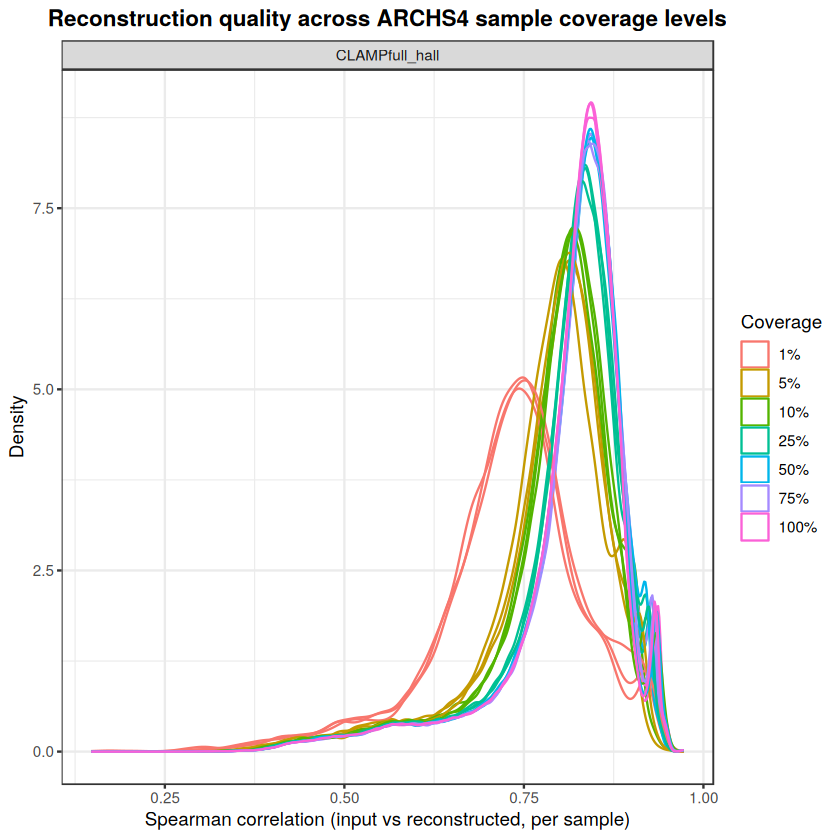

In [4]:
# Expand per-sample correlation vectors for density plots
cor_long <- dplyr::bind_rows(
  lapply(results_list, function(x) {
    data.frame(
      coverage_pct = x$coverage_pct,
      seed         = x$seed,
      model        = x$model,
      cor          = x$cor_vector[[1]],
      stringsAsFactors = FALSE
    )
  })
)

cor_long$coverage_label <- factor(
  paste0(cor_long$coverage_pct, "%"),
  levels = paste0(c(1, 5, 10, 25, 50, 75, 100), "%")
)

# --- Plot 1: density of per-sample correlations, faceted by model ---
p_density <- ggplot2::ggplot(cor_long,
    ggplot2::aes(x = cor, colour = coverage_label, group = interaction(coverage_label, seed))) +
  ggplot2::geom_density(alpha = 0.4) +
  ggplot2::facet_wrap(~ model) +
  ggplot2::theme_bw() +
  ggplot2::labs(
    x      = "Spearman correlation (input vs reconstructed, per sample)",
    y      = "Density",
    colour = "Coverage",
    title  = "Reconstruction quality across ARCHS4 sample coverage levels"
  ) +
  ggplot2::theme(plot.title = ggplot2::element_text(hjust = 0.5, face = "bold"))

p_density

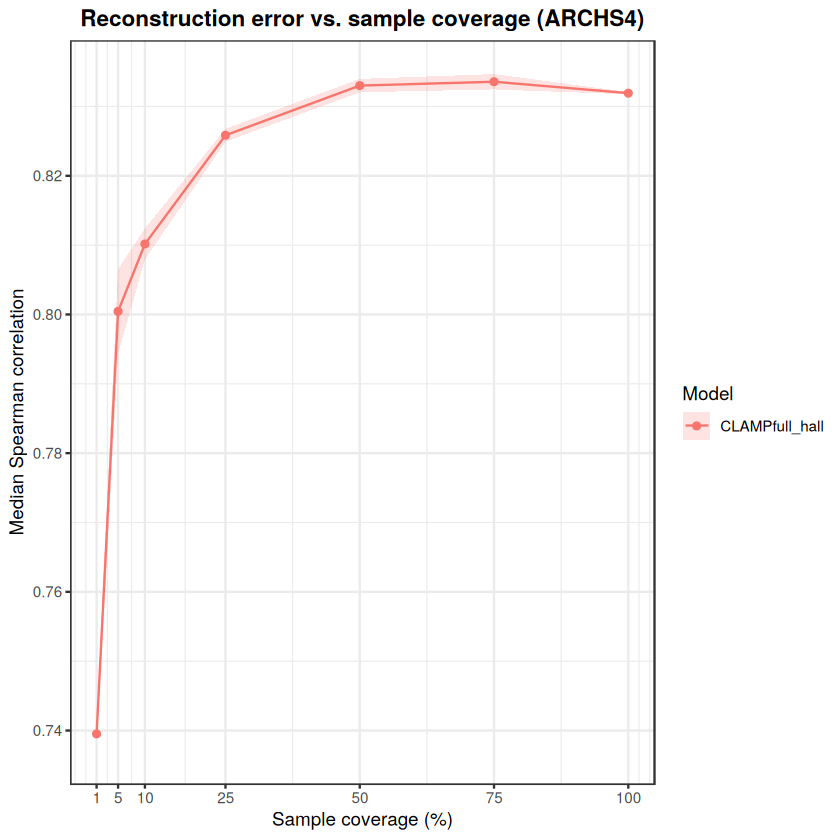

In [5]:
# --- Plot 2: median correlation vs coverage %, ribbon = sd across seeds ---
summary_stats <- results_df %>%
  dplyr::group_by(coverage_pct, model) %>%
  dplyr::summarise(
    mean_median_cor = mean(median_cor),
    sd_median_cor   = sd(median_cor),
    .groups = "drop"
  )

p_line <- ggplot2::ggplot(summary_stats,
    ggplot2::aes(x = coverage_pct, y = mean_median_cor,
                 colour = model, fill = model)) +
  ggplot2::geom_line() +
  ggplot2::geom_point() +
  ggplot2::geom_ribbon(
    ggplot2::aes(ymin = mean_median_cor - sd_median_cor,
                 ymax = mean_median_cor + sd_median_cor),
    alpha = 0.2, colour = NA
  ) +
  ggplot2::scale_x_continuous(breaks = c(1, 5, 10, 25, 50, 75, 100)) +
  ggplot2::theme_bw() +
  ggplot2::labs(
    x      = "Sample coverage (%)",
    y      = "Median Spearman correlation",
    colour = "Model",
    fill   = "Model",
    title  = "Reconstruction error vs. sample coverage (ARCHS4)"
  ) +
  ggplot2::theme(plot.title = ggplot2::element_text(hjust = 0.5, face = "bold"))

p_line